# YOLOv5n — Construction Site Safety Detection

**Model:** YOLOv5n
**Task:** Object detection — 3 classes: helmet, vest, head

---

## 1. Install & Import

In [1]:
!pip install -q ultralytics opencv-python-headless seaborn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
amazon-sagemaker-jupyter-ai-q-developer 1.2.9 requires numpy<=2.0.1, but you have numpy 2.4.5 which is incompatible.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.5 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.5 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.5 which is incompatible.
autogluon-features 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have 

In [2]:
%matplotlib inline
import os
import gc
import json
import glob
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

plt.rcParams['figure.dpi'] = 100

## 2. Configuration

In [ ]:
DATASET_ROOT = '/home/sagemaker-user/assignment 3/construction-safety/project/dataset'

BASE_DIR = os.path.abspath(os.path.dirname(DATASET_ROOT.rstrip('/')))
IMAGES_DIR = os.path.join(DATASET_ROOT, 'images')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output_yolov5n')    # where the data are stored after process
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ['helmet', 'vest', 'head']
NUM_CLASSES = 3
IMG_SIZE = 832
EPOCHS   = 60
PATIENCE = 12

RUN_DIR     = os.path.join(OUTPUT_DIR, 'train')
WEIGHTS_DIR = os.path.join(RUN_DIR, 'weights')
BEST_PT     = os.path.join(WEIGHTS_DIR, 'best.pt')
RESUME_LOG  = os.path.join(OUTPUT_DIR, 'resume_log.txt')
STATUS_FILE = os.path.join(OUTPUT_DIR, 'status.json')   

print('Kernel working dir :', os.getcwd())
print('OUTPUT_DIR         :', OUTPUT_DIR)
print('Dataset            :', DATASET_ROOT)

Kernel working dir : /home/sagemaker-user/assignment 3/construction-safety/project/notebooks
OUTPUT_DIR         : /home/sagemaker-user/assignment 3/construction-safety/project/output_yolov5n
Dataset            : /home/sagemaker-user/assignment 3/construction-safety/project/dataset


## 3. Status Tracking + Helpers

In [ ]:
def load_status():       # to check status if training is complete

    if os.path.exists(STATUS_FILE):
        with open(STATUS_FILE) as f:
            return json.load(f)
    return {'trained': False, 'evaluated': False}

def save_status(status):         # save status during and after training
    
    with open(STATUS_FILE, 'w') as f:
        json.dump(status, f, indent=2)

def log_event(msg):               # save timestamps for debugging
    
    stamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{stamp}] {msg}'
    with open(RESUME_LOG, 'a') as f:
        f.write(line + '\n')
    print(line)

def free_memory(*objs):           # prevent crashes due to sagemaker limit

    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

status = load_status()
print('Current status:', status)

Current status: {'trained': False, 'evaluated': False}


## 4. Write dataset YAML

In [ ]:
yaml_text = (
    f"path: {DATASET_ROOT}\n"
    f"train: images/train\nval: images/val\ntest: images/test\n"
    f"nc: {NUM_CLASSES}\nnames: {CLASS_NAMES}\n"
)
DATA_YAML = os.path.join(OUTPUT_DIR, 'data_3class.yaml')
with open(DATA_YAML, 'w') as f:
    f.write(yaml_text)
print('Wrote', DATA_YAML)          # Create YAML file for ultralytics. forcing nc:3 so it trains on our data rather than COCO.

Wrote /home/sagemaker-user/assignment 3/construction-safety/project/output_yolov5n/data_3class.yaml


## Phase 1 — Train YOLOv5n

In [ ]:
import glob, re

def newest_epoch_ckpt():        # check for already processed epoche when restarting. 
    
    cks = glob.glob(os.path.join(WEIGHTS_DIR, 'epoch*.pt'))
    best_n, best_p = -1, None
    for p in cks:
        m = re.search(r'epoch(\d+)\.pt$', os.path.basename(p))
        if m:
            n = int(m.group(1))
            if n > best_n:
                best_n, best_p = n, p
    return best_p, best_n

def assert_3class(model):         # to verify its running on our dataset and mot COCO.
    
    nc = model.model.model[-1].nc if hasattr(model.model, 'model') else None
    assert nc == NUM_CLASSES, (
        f'Loaded checkpoint has nc={nc}, expected {NUM_CLASSES}. '
        f'Refusing to train — this is NOT our construction model.')

if status.get('trained'):       # training completed. skip all
    log_event('Phase 1 SKIPPED — training already completed previously '
              '(status.trained=True).')

if training_done:
    if not status.get('trained'):
        status['trained'] = True
        save_status(status)
        log_event('Phase 1 RECOVERED — best.pt exists; training already '
                  'complete. Not retraining.')
    else:
        log_event('Phase 1 SKIPPED — training already completed previously.')
else:      # continue training after failure
    ckpt_path, ckpt_epoch = newest_epoch_ckpt()

    if ckpt_path is not None:
        # ---- WARM-RESTART RESUME ----
        log_event(f'Phase 1 RESUME — loading {os.path.basename(ckpt_path)} '
                  f'(epoch {ckpt_epoch}). Continuing training, EXPLICIT '
                  f'data=DATA_YAML, no resume=True.')
        model = YOLO(ckpt_path)          
        assert_3class(model)             
        remaining = max(EPOCHS - ckpt_epoch, 1)
        log_event(f'   {ckpt_epoch} epochs done, training {remaining} more '
                  f'(target {EPOCHS}).')
        model.train(
            data=DATA_YAML, imgsz=IMG_SIZE, epochs=remaining, batch=32,
            patience=PATIENCE, optimizer='SGD',
            project=OUTPUT_DIR, name='train', exist_ok=True,
            plots=True, verbose=True, save_period=1, val=False,
        )
    else:
        # ---- FRESH START ----
        log_event('Phase 1 FRESH START — COCO-pretrained, EXPLICIT '
                  'data=DATA_YAML (cannot fall back to coco8).')
        model = YOLO('yolov5n.pt')
        model.train(
            data=DATA_YAML, imgsz=IMG_SIZE, epochs=EPOCHS, batch=32,
            patience=PATIENCE, optimizer='SGD',
            project=OUTPUT_DIR, name='train', exist_ok=True,
            plots=True, verbose=True, save_period=1, val=False,    #val off because it kept crashing kernal in sagemaker. maybe dataset too big.
        )

    assert os.path.exists(BEST_PT), 'best.pt not created — training failed.'
    status['trained'] = True
    save_status(status)
    log_event('Phase 1 COMPLETE — training finished, status saved.')
    free_memory(model)
    log_event('Memory freed after training.')

print('Phase 1 state: trained =', load_status()['trained'])
print('best.pt exists:', os.path.exists(BEST_PT))

[2026-05-18 03:14:53] Phase 1 FRESH START — COCO-pretrained, EXPLICIT data=DATA_YAML (cannot fall back to coco8).
PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.51 🚀 Python-3.12.9 torch-2.6.0 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/sagemaker-user/assignment 3/construction-safety/project/output_yolov5n/data_3class.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, flip

2026/05/18 03:15:08 INFO mlflow.tracking.fluent: Experiment with name '/home/sagemaker-user/assignment 3/construction-safety/project/output_yolov5n' does not exist. Creating a new experiment.


MLflow: logging run_id(888c3ff8de7b42c4afbd2da9387e08d8) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 832 train, 832 val
Using 4 dataloader workers
Logging results to /home/sagemaker-user/assignment 3/construction-safety/project/output_yolov5n/train
Starting training for 60 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/60      12.1G      1.648      1.684      1.327        410        832: 100% ━━━━━━━━━━━━ 539/539 1.9it/s 4:43<0.5s

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/60      10.2G      1.573      1.066      1.213        432        832: 100% ━━━━━━━━━━━━ 539/539 2.0it/s 4:27<0.5s

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/60      11.7G      1.578      1.033      1.204        615        832: 100% ━━━━━━━━━━━━ 539/539 2.0i

## Phase 2 — Evaluate (Train / Val / Test)

In [ ]:
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.json')

if status.get('evaluated') and os.path.exists(metrics_path): # Already evaluated, load from disk
    log_event('Phase 2 SKIPPED — evaluation already done. Loading saved metrics.')
    with open(metrics_path) as f:
        metrics = json.load(f)
else:
    assert os.path.exists(BEST_PT), (
        f'best.pt not found at {BEST_PT}. Training may not have finished.')
    eval_model = YOLO(BEST_PT)             
    metrics = {}
    for split in ['train', 'val', 'test']:
        m = eval_model.val(data=DATA_YAML, imgsz=IMG_SIZE,
                           split=split, verbose=False)     #runs the model on every image and computes detection metrics
        metrics[split] = {
            'mAP@0.5':      float(m.box.map50),
            'mAP@0.5:0.95': float(m.box.map),
            'precision':    float(m.box.mp),
            'recall':       float(m.box.mr),
            'per_class_AP@0.5': {
                CLASS_NAMES[i]: float(m.box.ap50[i])
                for i in range(len(CLASS_NAMES)) if i < len(m.box.ap50)
            },
        }
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=2)
    status['evaluated'] = True
    save_status(status)
    log_event('Phase 2 COMPLETE — metrics saved.')
    free_memory(eval_model)

print('=' * 68)
print(f"{'Split':<10}{'mAP@0.5':>12}{'mAP@.5:.95':>14}{'Precision':>12}{'Recall':>10}")
print('-' * 68)
for split in ['train', 'val', 'test']:
    r = metrics[split]
    print(f"{split:<10}{r['mAP@0.5']:>12.4f}{r['mAP@0.5:0.95']:>14.4f}"
          f"{r['precision']:>12.4f}{r['recall']:>10.4f}")
print('=' * 68)
print('\nPer-class AP@0.5 (TEST):')
for cls, ap in metrics['test']['per_class_AP@0.5'].items():
    print(f"  {cls:<8}: {ap:.4f}")

Ultralytics 8.4.51 🚀 Python-3.12.9 torch-2.6.0 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5n summary (fused): 85 layers, 2,503,529 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 1.2±1.7 ms, read: 152.5±27.1 MB/s, size: 131.4 KB)
val: Scanning /home/sagemaker-user/assignment 3/construction-safety/project/dataset/labels/train.cache... 17248 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17248/17248 4.8Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1078/1078 5.6it/s 3:11<0.2s
                   all      17248     148487       0.92      0.909      0.955      0.624
Speed: 1.4ms preprocess, 5.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /home/sagemaker-user/assignment 3/construction-safety/project/notebooks/runs/detect/val
Ultralytics 8.4.51 🚀 Python-3.12.9 torch-2.6.0 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 135.5±47.5 MB/s, size: 258.7 KB)

## Phase 3 — Visualizations

Curves, confusion matrix, correct/incorrect examples. 

### 3a. Training Curves

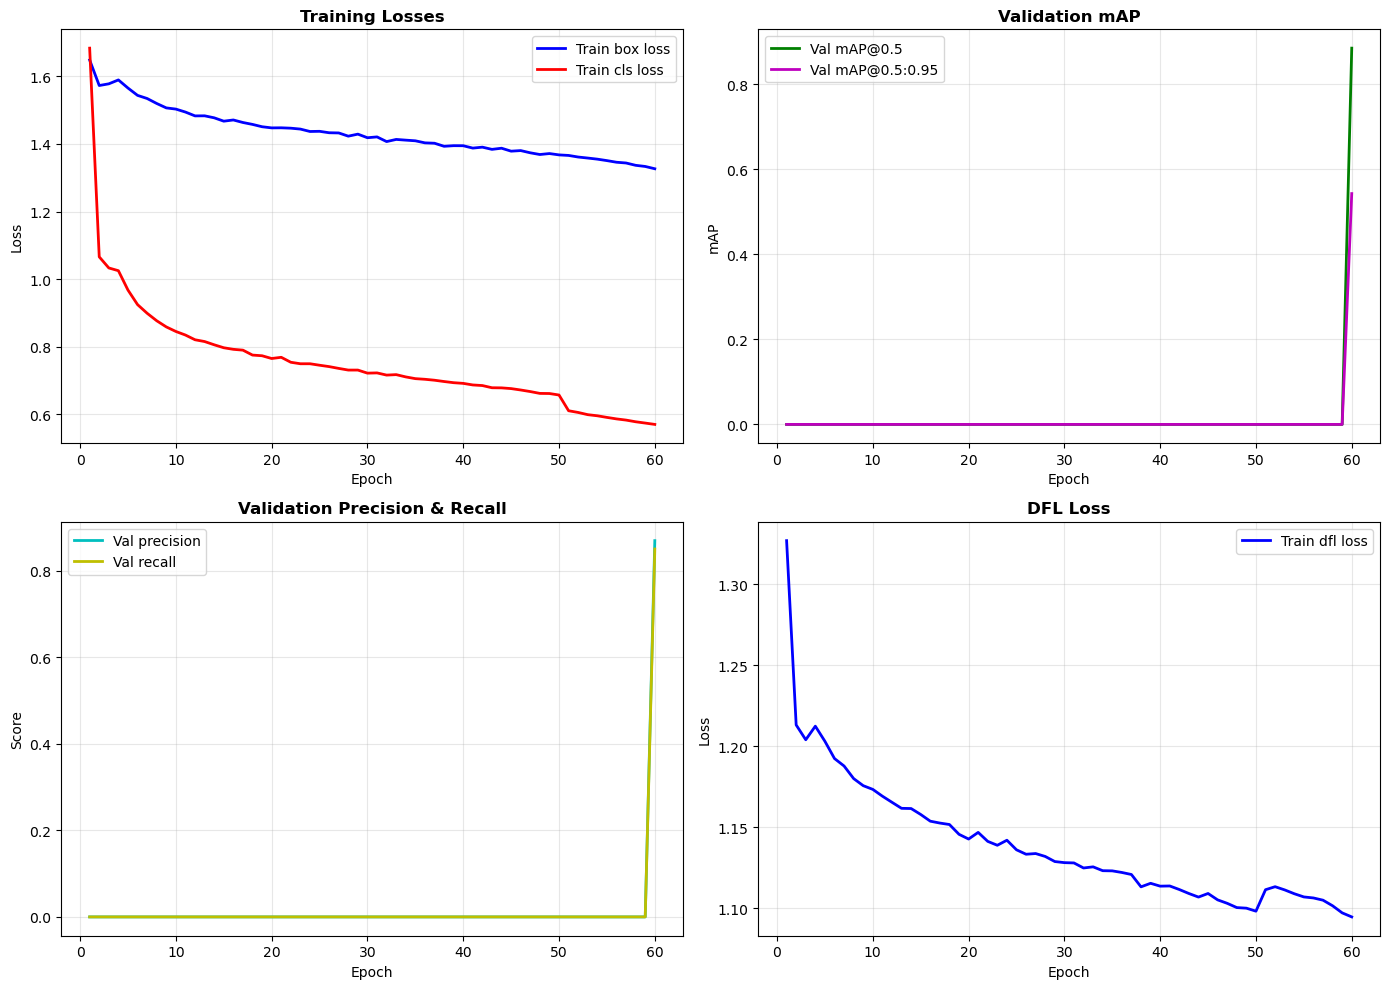

In [9]:
df = pd.read_csv(os.path.join(RUN_DIR, 'results.csv'))
df.columns = df.columns.str.strip()
ep = df['epoch']

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax[0,0].plot(ep, df['train/box_loss'], 'b-', label='Train box loss', linewidth=2)
ax[0,0].plot(ep, df['train/cls_loss'], 'r-', label='Train cls loss', linewidth=2)
ax[0,0].set_title('Training Losses', fontsize=12, fontweight='bold')
ax[0,0].set_xlabel('Epoch'); ax[0,0].set_ylabel('Loss')
ax[0,0].legend(); ax[0,0].grid(True, alpha=0.3)

ax[0,1].plot(ep, df['metrics/mAP50(B)'], 'g-', label='Val mAP@0.5', linewidth=2)
ax[0,1].plot(ep, df['metrics/mAP50-95(B)'], 'm-', label='Val mAP@0.5:0.95', linewidth=2)
ax[0,1].set_title('Validation mAP', fontsize=12, fontweight='bold')
ax[0,1].set_xlabel('Epoch'); ax[0,1].set_ylabel('mAP')
ax[0,1].legend(); ax[0,1].grid(True, alpha=0.3)

ax[1,0].plot(ep, df['metrics/precision(B)'], 'c-', label='Val precision', linewidth=2)
ax[1,0].plot(ep, df['metrics/recall(B)'], 'y-', label='Val recall', linewidth=2)
ax[1,0].set_title('Validation Precision & Recall', fontsize=12, fontweight='bold')
ax[1,0].set_xlabel('Epoch'); ax[1,0].set_ylabel('Score')
ax[1,0].legend(); ax[1,0].grid(True, alpha=0.3)

if 'train/dfl_loss' in df.columns:
    ax[1,1].plot(ep, df['train/dfl_loss'], 'b-', label='Train dfl loss', linewidth=2)
    ax[1,1].set_title('DFL Loss', fontsize=12, fontweight='bold')
    ax[1,1].set_xlabel('Epoch'); ax[1,1].set_ylabel('Loss')
    ax[1,1].legend(); ax[1,1].grid(True, alpha=0.3)
else:
    ax[1,1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### 3b. Confusion Matrix

Ultralytics 8.4.51 🚀 Python-3.12.9 torch-2.6.0 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5n summary (fused): 85 layers, 2,503,529 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1718.9±343.0 MB/s, size: 146.0 KB)
val: Scanning /home/sagemaker-user/assignment 3/construction-safety/project/dataset/labels/test.cache... 2455 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2455/2455 858.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 154/154 5.7it/s 27.3s0.2s
                   all       2455      20193      0.889      0.845      0.895      0.548
                helmet       1822       6749      0.942      0.855      0.917      0.615
                  vest        440        935      0.815      0.773      0.852      0.532
                  head        713      12509       0.91      0.905      0.917      0.498
Speed: 1.4ms preprocess, 5.3ms inference, 0.0ms loss, 0.7ms postprocess per imag

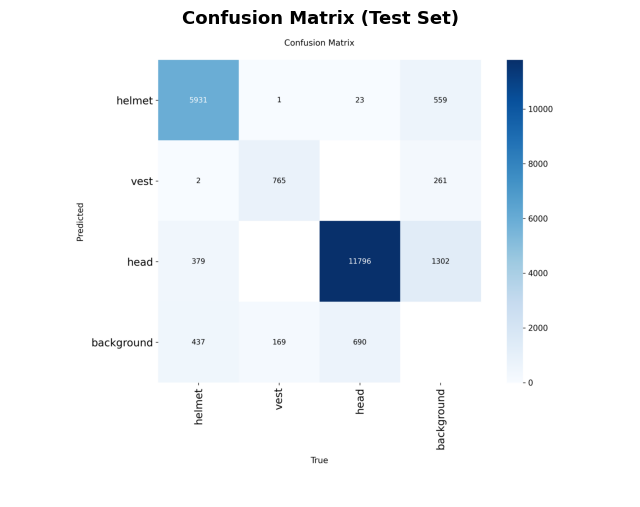

In [ ]:
cm_model = YOLO(BEST_PT)           
cm_model.val(data=DATA_YAML, imgsz=IMG_SIZE, split='test',
             plots=True, project=OUTPUT_DIR, name='test_eval', exist_ok=True)
cm_path = os.path.join(OUTPUT_DIR, 'test_eval', 'confusion_matrix.png')
if os.path.exists(cm_path):
    plt.figure(figsize=(8, 7))
    plt.imshow(Image.open(cm_path)); plt.axis('off')
    plt.title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'),
                dpi=100, bbox_inches='tight')
    plt.show()
free_memory(cm_model)
plt.show()

### 3c. Correct vs Incorrect Detections

Scoring test images:   0%|          | 0/2455 [00:00<?, ?it/s]

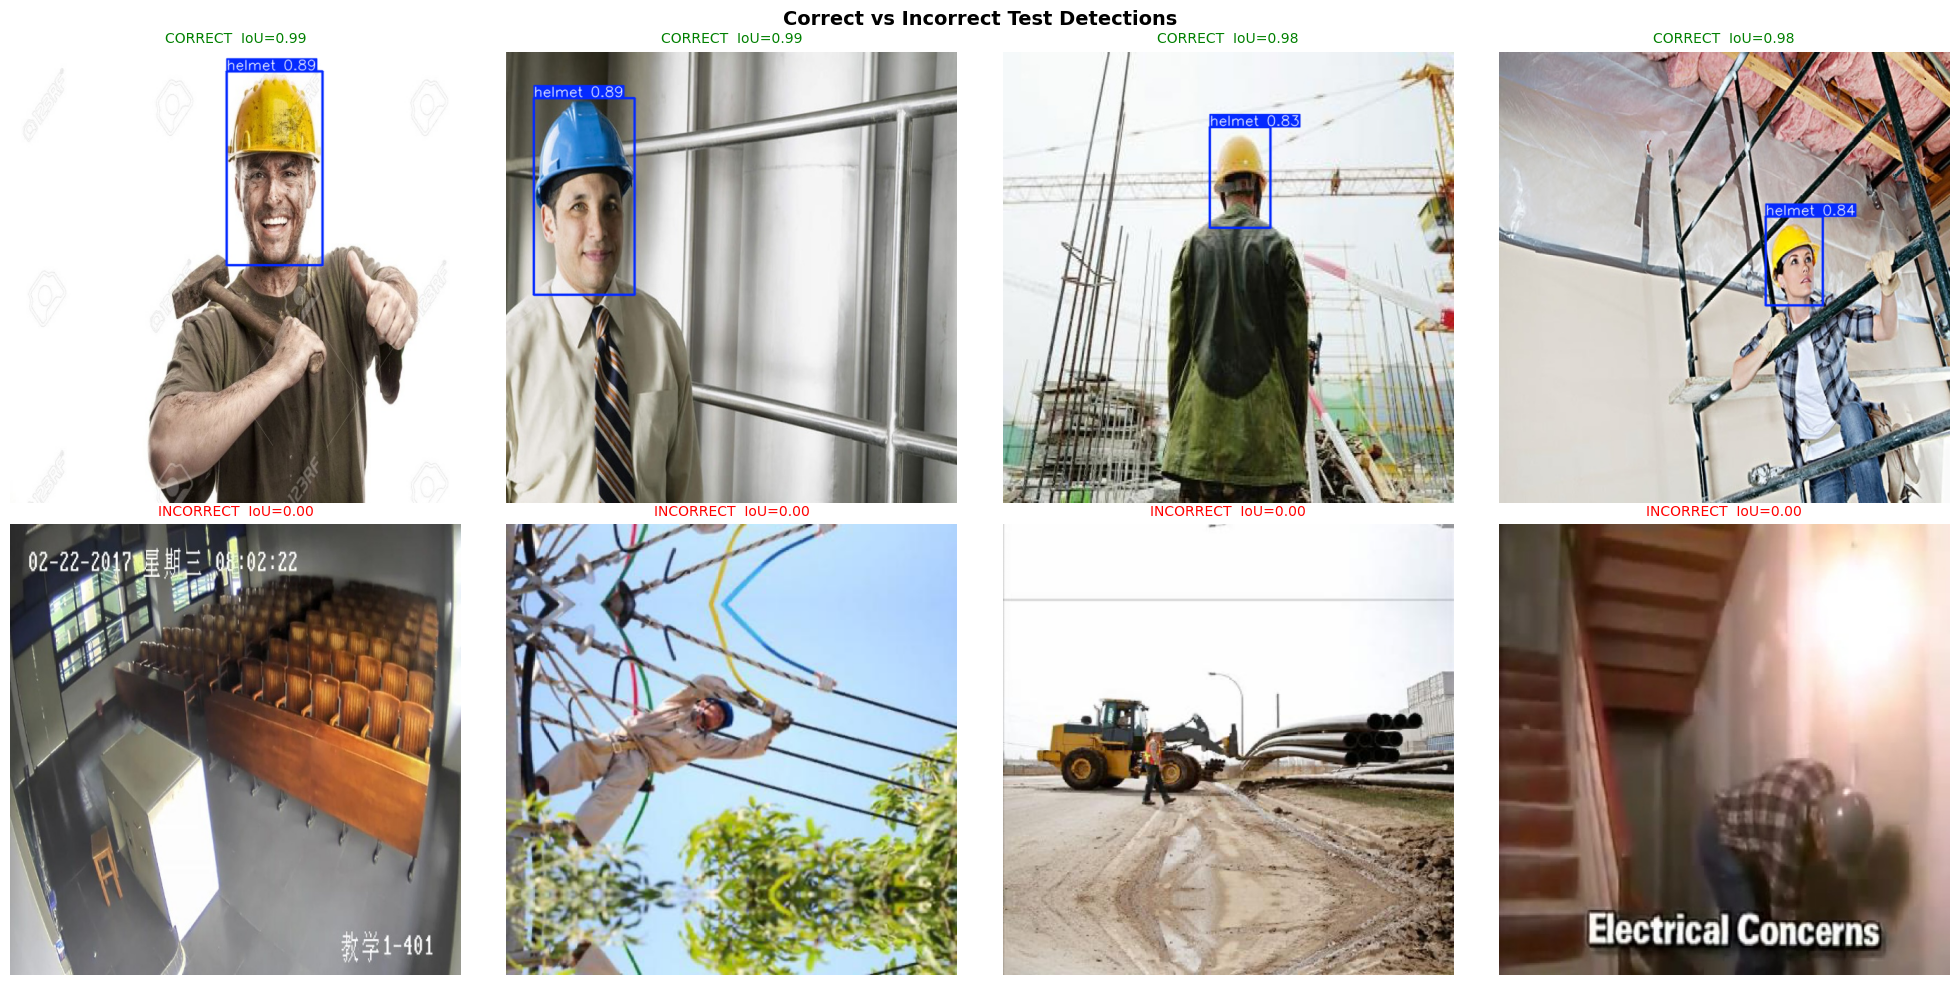

In [ ]:
def read_gt_boxes(label_path, img_w, img_h):
    boxes = []
    if os.path.exists(label_path):
        for line in open(label_path):
            parts = line.split()
            if len(parts) != 5:
                continue
            _, cx, cy, bw, bh = parts
            cx, cy, bw, bh = float(cx), float(cy), float(bw), float(bh)
            boxes.append([(cx-bw/2)*img_w, (cy-bh/2)*img_h,
                          (cx+bw/2)*img_w, (cy+bh/2)*img_h])
    return np.array(boxes)

def iou(a, b):
    xA=max(a[0],b[0]); yA=max(a[1],b[1])
    xB=min(a[2],b[2]); yB=min(a[3],b[3])
    inter=max(0,xB-xA)*max(0,yB-yA)
    union=(a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/union if union>0 else 0.0

vis_model = YOLO(BEST_PT)         
test_img_dir = os.path.join(IMAGES_DIR, 'test')
test_lbl_dir = os.path.join(LABELS_DIR, 'test')
test_files = sorted(os.listdir(test_img_dir))

scores = []
for fn in tqdm(test_files, desc='Scoring test images'):
    stem = os.path.splitext(fn)[0]
    img = Image.open(os.path.join(test_img_dir, fn)); W, H = img.size
    gt = read_gt_boxes(os.path.join(test_lbl_dir, stem + '.txt'), W, H)
    if len(gt) == 0:
        continue
    pred = vis_model(os.path.join(test_img_dir, fn),
                     imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
    pb = pred.boxes.xyxy.cpu().numpy() if pred.boxes is not None else np.zeros((0,4))
    mi = 0.0 if len(pb)==0 else float(np.mean(
        [max(iou(g, p) for p in pb) for g in gt]))
    scores.append((fn, mi))

scores.sort(key=lambda x: x[1], reverse=True)
chosen = scores[:4] + scores[-4:]

import cv2
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
for i, (fn, sc) in enumerate(chosen):
    pred = vis_model(os.path.join(test_img_dir, fn),
                     imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
    ax[i//4, i%4].imshow(cv2.cvtColor(pred.plot(), cv2.COLOR_BGR2RGB))
    tag = 'CORRECT' if i < 4 else 'INCORRECT'
    ax[i//4, i%4].set_title(f"{tag}  IoU={sc:.2f}", fontsize=10,
                            color='green' if i < 4 else 'red')
    ax[i//4, i%4].axis('off')
plt.suptitle('Correct vs Incorrect Test Detections', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correct_vs_incorrect.png'),
            dpi=100, bbox_inches='tight')
plt.show()
free_memory(vis_model)
plt.show()